# Data Audit — 080718_mitt session

**What is this notebook?**
Before we can train any model, we need to understand the raw data we were given: what's actually inside these files, what the numbers mean, and whether our assumptions about the data match reality. This notebook is that investigation, done once per rat/session, on one rat first (Mitt, recorded July 18, 2008) before touching the rest.


**High-level goal of this session's audit:** confirm what each data file contains, extract a clean list of trials with two labels per trial (InSeq/OutSeq, and which odor A–E), and get real numbers (sampling rate, trial spacing) that later code will depend on.


## 1. Setup

In [1]:
import sys
sys.path.append('..')  # lets us import from the src/ folder one level up
from src.data_loading import inspect_npz, inspect_session
from pathlib import Path


## 2. Looking at Data within Folders


In [2]:
for p in sorted(Path('../data/raw').iterdir()):
    print(p)


../data/raw/.DS_Store
../data/raw/080718_mitt
../data/raw/081106_barat
../data/raw/090212_stella
../data/raw/090212_superchris
../data/raw/090420_buchanan


**Finding:** five session folders, one per rat, named `YYMMDD_ratname`
(`080718_mitt`, `081106_barat`, `090212_stella`, `090212_superchris`, `090420_buchanan`).
Reading the numbers as `YYMMDD` (not `MMDDYY`), all five sessions fall between July 2008 and April 2009,
about 10 months apart. `090212` appearing twice (Stella and Superchris)
suggests both rats were recorded on the same day.


## 3. Inspect every file in one session

This opens all four data files for one rat and prints a summary of what's inside each one, like a table of contents.

In [3]:
session_dir = '../data/raw/080718_mitt'  # one rat, one session — start small on purpose
results = inspect_session(session_dir)



File: 080718_mitt_bvr.npz
  data                 shape=(18, 5255152)   dtype=float64
  keys                 shape=(18,)           dtype=<U19
                       values=['TimeBin', 'Odor1', 'Odor2', 'Odor3', 'Odor4', 'Odor5', 'Position1', 'Position2', 'Position3', 'Position4', 'Position5', 'InSeqLog', 'PerformanceLog', 'PokeEvents', 'FrontReward', 'BackReward', 'XvalRatMazePosition', 'YvalRatMazePosition']

File: 080718_mitt_lfp.npz
  keys                 shape=(22,)           dtype=<U11
  data                 shape=(22, 5255152)   dtype=float64

File: 080718_mitt_spk.npz
  keys                 shape=(104,)          dtype=<U7
  data                 shape=(104, 5255152)  dtype=float64

File: 080718_mitt_wfm.npz
  keys                 shape=(104,)          dtype=<U7
  data                 shape=(104, 128)      dtype=float64
  std                  shape=(104, 128)      dtype=float64


**Findings from this session's four files:**

| File | Shape | What it is |
|---|---|---|
| `bvr` | 18 rows × 5,255,152 timepoints | Behavioral variables over time (odors, positions, trial events, reward) |
| `lfp` | 22 rows × 5,255,152 timepoints | Raw LFP voltage from 22 electrodes |
| `spk` | 104 rows × 5,255,152 timepoints | Spike activity from 104 sorted neurons |
| `wfm` | 104 rows × 128 samples (+ std) | Average spike waveform shape per neuron — not a time series, just a shape template |

The key thing that jumps out: `bvr`, `lfp`, and `spk` all have **exactly the same number of timepoints**
(5,255,152). That means behavior, LFP, and spikes are already perfectly aligned on one shared time axis,
sample for sample. We don't need to do any separate alignment work, index `i` means the same moment in
time across all three files.


## 4. Look inside the behavioral file in detail

Now that we know `bvr` has 18 rows, let's see what each one actually contains: its range of values, how
many distinct values it takes, and how often it's nonzero. This tells us, without reading any
documentation, which channels are binary event markers (like a light switch) versus continuous
measurements (like a thermometer).

In other words, for each of the 18 behavior columns, print its smallest and largest value, how many different values it has, and how many times it's not zero. A column with only 2 unique values (0 and 1) is probably an on/off switch. A column with thousands of unique values is probably a continuous measurement.


In [4]:
import numpy as np

bvr = np.load('../data/raw/080718_mitt/080718_mitt_bvr.npz', allow_pickle=True)
data = bvr['data']   # shape (18, 5255152) — 18 behavioral channels over time
keys = bvr['keys']   # the 18 channel names, e.g. 'Odor1', 'InSeqLog', ...

for i, k in enumerate(keys):
    row = data[i]
    print(f"{i:2d} {k:22s} min={row.min():.4f} max={row.max():.4f} "
          f"unique={len(np.unique(row)):6d} nonzero={np.count_nonzero(row)}")


 0 TimeBin                min=0.0106 max=7359.6346 unique=5255152 nonzero=5255152
 1 Odor1                  min=0.0000 max=1.0000 unique=     2 nonzero=83
 2 Odor2                  min=0.0000 max=1.0000 unique=     2 nonzero=65
 3 Odor3                  min=0.0000 max=1.0000 unique=     2 nonzero=60
 4 Odor4                  min=0.0000 max=1.0000 unique=     2 nonzero=44
 5 Odor5                  min=0.0000 max=1.0000 unique=     2 nonzero=40
 6 Position1              min=0.0000 max=1.0000 unique=     2 nonzero=79
 7 Position2              min=0.0000 max=1.0000 unique=     2 nonzero=63
 8 Position3              min=0.0000 max=1.0000 unique=     2 nonzero=58
 9 Position4              min=0.0000 max=1.0000 unique=     2 nonzero=51
10 Position5              min=0.0000 max=1.0000 unique=     2 nonzero=41
11 InSeqLog               min=-1.0000 max=1.0000 unique=     3 nonzero=292
12 PerformanceLog         min=-1.0000 max=1.0000 unique=     3 nonzero=292
13 PokeEvents             min=-1.0000 

**Findings:**
- `Odor1`–`Odor5` and `Position1`–`Position5`: all binary (0/1), each nonzero only a few dozen times.
  These look like brief on/off markers per trial.
- `InSeqLog`, `PerformanceLog`, `PokeEvents`: three values (`-1, 0, 1`), each nonzero exactly **292**
  times. That repeated number 292 across several channels is the tell that this session has **292
  total trials**, and each one is marked by a single sample, not a stretch of time.
- `FrontReward` / `BackReward`: binary, 230 and 27 nonzero respectively (230 + 27 = 257, close to but
  not exactly 292, meaning some trials got no reward — a first hint that those are the incorrect
  trials).
- `XvalRatMazePosition` / `YvalRatMazePosition`: continuous, thousands of unique values, this is the
  literal x/y position of the rat on the maze, tracked constantly, not just at trial moments.

Five columns are about which odor was presented, five are about maze position zones, three mark trial events (using -1/0/1), two mark reward delivery, and two are the rat's continuous x/y coordinates.


## 5. Figure out the real sampling rate

We know there are 5,255,152 timepoints, but not yet how much real time that spans. The `TimeBin`
channel should be actual timestamps (in seconds), so the gap between consecutive values tells us the
sampling interval, and its inverse gives us the sampling rate in Hz.

This figures out how many data points we get per second, and how long the whole recording lasted in minutes. We need this number for almost everything downstream (defining window lengths, converting sample counts to real time).


In [5]:
timebin = data[list(keys).index('TimeBin')]
print("First 10 TimeBin values:", timebin[:10])
diffs = np.diff(timebin)
print("Mean interval:", diffs.mean())
print("Implied sampling rate (Hz):", 1 / diffs.mean())
print("Total recording duration (minutes):", (timebin[-1] - timebin[0]) / 60)


First 10 TimeBin values: [0.010575 0.011575 0.012575 0.013575 0.014575 0.015575 0.016575 0.017575
 0.018575 0.019575]
Mean interval: 0.0014004590924218924
Implied sampling rate (Hz): 714.0515602427515
Total recording duration (minutes): 122.6604


**Findings:** ~714 Hz sampling rate, ~123 minutes total recording.

About 714 data points represent one second of real time, and the whole recording is about 2 hours long.


## 6. Pull out the actual trial events and labels

We find every timepoint where `InSeqLog` fires (that's a trial marker), and look
at its value (that's our InSeq/OutSeq label). We also check `PerformanceLog` at the same spots as a
cross-check, and measure the time gap between consecutive trials to make sure our later window size
won't accidentally overlap two trials.

This finds the exact moment of every one of the 292 trials, reads off whether it was InSeq or OutSeq, whether the rat got it right, and how much breathing room we have between trials.


In [6]:
idx = np.where(data[keys.tolist().index('InSeqLog')] != 0)[0]
inseq_vals = data[keys.tolist().index('InSeqLog')][idx]
perf_vals = data[keys.tolist().index('PerformanceLog')][idx]

print("Number of trial events found:", len(idx))
print("First 10 trial indices:", idx[:10])
print("First 10 InSeqLog values at those indices:", inseq_vals[:10])
print("First 10 PerformanceLog values at those indices:", perf_vals[:10])
print("InSeqLog value counts:", dict(zip(*np.unique(inseq_vals, return_counts=True))))
print("PerformanceLog value counts:", dict(zip(*np.unique(perf_vals, return_counts=True))))

# gap between consecutive trial events, in seconds, using our measured sampling rate
gaps_sec = np.diff(idx) / 714.05
print("Median gap between trials (sec):", np.median(gaps_sec))
print("Min gap between trials (sec):", np.min(gaps_sec))


Number of trial events found: 292
First 10 trial indices: [ 87791  91309  94331 109672 129600 142967 174141 187169 190864 210349]
First 10 InSeqLog values at those indices: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
First 10 PerformanceLog values at those indices: [ 1.  1.  1. -1.  1.  1.  1.  1. -1.  1.]
InSeqLog value counts: {-1.0: 30, 1.0: 262}
PerformanceLog value counts: {-1.0: 46, 1.0: 246}
Median gap between trials (sec): 7.849590364820391
Min gap between trials (sec): 3.876479238148589


**Findings — this is the key result of the whole audit:**
- **292 trials confirmed.** `InSeqLog` splits into `-1.0: 30` (OutSeq) and `1.0: 262` (InSeq).
  That's roughly a 90/10 split, and it's not noise or a data problem, it's the task design: OutSeq
  trials are deliberately rare "probe" trials sprinkled among mostly-InSeq trials. This means plain
  accuracy is a misleading metric later (guessing "InSeq" every time already scores ~90%), we'll want
  balanced accuracy or F1 when comparing to the paper's benchmark.
- `PerformanceLog` splits `-1.0: 46` (incorrect) and `1.0: 246` (correct), roughly consistent with the
  reward-channel count from Section 4.
- **Minimum gap between trials: 3.88 seconds.** Our planned window length (0.5 sec) fits with about
  7x headroom, no risk of one window accidentally spanning two trials.

Out of 292 trials, the rat saw the "correct order" sequence 262 times and a "wrong order" trick trial 30 times. It got the answer right 246 times. And trials happen far enough apart in time that we can safely grab a small chunk of data around each one without bumping into the next trial.


## 7. Confirm the odor identity (second label)

We know *when* each trial happens and whether it's InSeq/OutSeq. We still need *which odor* (A–E) was
presented, that's the second thing our model needs to predict. `Odor1`–`Odor5` should tell us, but we
need to check whether the timing lines up cleanly with the trial marker, or whether odor presentation
starts noticeably earlier.

For each trial, we look just before the trial marker and see which one of the five Odor
columns was turned on. If exactly one is on for every trial, we have a clean, unambiguous label.


In [7]:
odor_names = ['Odor1', 'Odor2', 'Odor3', 'Odor4', 'Odor5']
odor_rows = [data[keys.tolist().index(name)] for name in odor_names]

# for each trial index, look in a window just before it for which Odor channel fired
window_before = 200  # samples, ~0.28 sec at 714 Hz, adjust if needed
trial_odors = []
for t in idx:
    start = max(0, t - window_before)
    active = [i for i, row in enumerate(odor_rows) if row[start:t+1].any()]
    trial_odors.append(active)

# sanity check: does every trial have exactly one active odor channel?
lengths = [len(a) for a in trial_odors]
print("Trials with exactly 1 odor active:", sum(l == 1 for l in lengths))
print("Trials with 0 odor active:", sum(l == 0 for l in lengths))
print("Trials with >1 odor active:", sum(l > 1 for l in lengths))
print("First 10 trial odor assignments:", trial_odors[:10])


Trials with exactly 1 odor active: 292
Trials with 0 odor active: 0
Trials with >1 odor active: 0
First 10 trial odor assignments: [[0], [1], [2], [3], [0], [1], [2], [3], [4], [0]]


**Finding: perfectly clean.** All 292 trials have exactly one odor channel active, zero
ambiguous or missing cases. `trial_odors` gives us index 0–4 per trial, mapping directly to Odor A–E
(`Odor1`→A, `Odor2`→B, etc., worth a quick double-check against the paper, but a very safe assumption).

Every single trial has one, and only one, clear odor label. We now have both labels we need for every trial, with no guessing or missing data.


## 8. Check exactly when the odor turns on, relative to the trial marker

This tells us how to define our data window: does `InSeqLog` fire at the *start* of odor presentation,
or later (e.g. at the moment of the InSeq/OutSeq judgment, after the rat has already been sampling the
odor for a bit)? That changes whether our window should look backward, forward, or centered around the
marker.

We measure, in real time, how far before the trial marker the corresponding odor channel first switched on.


In [8]:
onset_offsets = []
for t, active_list in zip(idx, trial_odors):
    if len(active_list) == 1:
        row = odor_rows[active_list[0]]
        # find where this odor channel first turns on, searching backward from t
        window = row[max(0, t-400):t+1]
        on_indices = np.where(window == 1)[0]
        if len(on_indices) > 0:
            onset_sample = max(0, t-400) + on_indices[0]
            onset_offsets.append(t - onset_sample)

onset_offsets = np.array(onset_offsets)
print("Median samples before trial marker odor turns on:", np.median(onset_offsets))
print("Median seconds before:", np.median(onset_offsets) / 714.05)
print("Min/max offset (samples):", onset_offsets.min(), onset_offsets.max())


Median samples before trial marker odor turns on: 0.0
Median seconds before: 0.0
Min/max offset (samples): 0 0


**Finding: offset is 0.** The odor channel turns on at the *exact same sample* as
`InSeqLog` fires. This corrects our initial mental model, `InSeqLog` isn't marking "the moment of
decision" some time after odor sampling begins, it's marking **odor onset itself**. Practical
consequence: our data window should start at (or just slightly before, for a small pre-stimulus
baseline) the trial index and extend *forward* in time, not backward.

The trial marker is the moment the odor turns on, not some later moment. So our window of data should mostly come from right after the marker, not before it.


## 9. Look at real LFP data around one trial

Everything above has been about labels and timing. Now let's actually look at the raw signal, four
electrode channels, a window of 600 samples (about 0.84 sec) centered near the very first trial, with
a red dashed line marking the exact moment `InSeqLog` fires.

This draws a picture of the actual brain electrical activity around one real trial, so we can see with our own eyes what the model will be looking at.


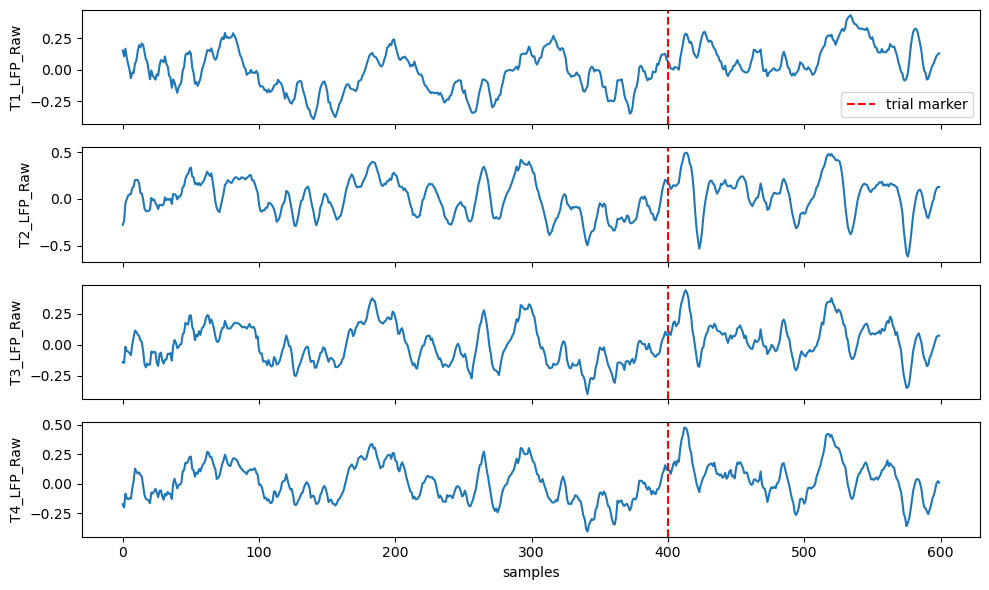

In [9]:
import matplotlib.pyplot as plt

lfp = np.load('../data/raw/080718_mitt/080718_mitt_lfp.npz', allow_pickle=True)
lfp_data = lfp['data']
lfp_keys = lfp['keys']

trial_idx = idx[0]  # first trial
window_start = trial_idx - 400
window_end = trial_idx + 200

fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True)
for ax, ch in zip(axes, range(4)):  # just first 4 channels for now
    ax.plot(lfp_data[ch, window_start:window_end])
    ax.axvline(trial_idx - window_start, color='red', linestyle='--', label='trial marker')
    ax.set_ylabel(lfp_keys[ch])
axes[0].legend()
axes[-1].set_xlabel('samples')
plt.tight_layout()
plt.show()


**Finding:** the four channels show clear rhythmic oscillations in the theta band
(roughly 4–8 Hz), the expected signature of hippocampal LFP during active behavior. There's no visible
jump, artifact, or discontinuity right at the trial marker.


## Summary

| Question | Answer |
|---|---|
| Sampling rate | ~714.05 Hz |
| Recording length | ~123 minutes |
| Total trials (this session) | 292 |
| InSeq / OutSeq split | 262 / 30 (imbalanced by design, not a data issue) |
| Correct / incorrect | 246 / 46 |
| Odor label quality | Clean, exactly 1 odor per trial, 0 ambiguous cases |
| Trial marker meaning | Marks **odor onset**, not decision moment (0 sample offset) |
| Minimum trial spacing | 3.88 sec (plenty of room for a 0.5 sec window) |
| Data alignment | `bvr`, `lfp`, `spk` share one identical time axis, no alignment work needed |

We now have everything needed to write real (non-stub) code in
`src/preprocessing.py`:
- `build_labels()`: read `InSeqLog` and the odor channel at each of the 292 trial indices.
- `segment_trials()`: cut a window starting at (or just before) each trial index, extending forward,
  from the `lfp` array.
